# Random Forest Modeling and Feature Importance Analysis

In [9]:
from statistics import mode

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split

In [10]:
data = pd.read_csv('../preprocessed_data/crd_preprocessed.csv')
data

,age,bmi,systolic_bp,diastolic_bp,cholesterol_mg_dl,resting_heart_rate,daily_steps,stress_level,physical_activity_hours_per_week,sleep_hours,family_history_heart_disease,diet_quality_score,alcohol_units_per_week,heart_disease_risk_score,risk_category,smoking_status_1,smoking_status_2
0,62,25.0,142,93,247,72,11565,3,5.6,8.2,0,7,0.7,28.1,1,0,0
1,54,29.7,158,101,254,74,4036,8,0.5,6.7,0,5,4.5,63.0,2,0,1
2,46,36.2,170,113,276,80,3043,9,0.4,4.0,0,1,20.8,73.1,2,0,1
3,48,30.4,153,98,230,73,5604,5,0.6,8.0,0,4,8.5,39.5,1,1,0
4,46,25.3,139,87,206,69,7464,1,2.0,6.1,0,5,3.6,29.3,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5495,19,26.0,121,75,185,84,6724,3,2.9,7.2,0,7,0.0,0.0,0,0,0
5496,18,30.9,128,82,235,75,3661,4,0.0,5.5,0,1,9.6,16.8,0,0,0
5497,63,29.5,142,92,239,69,6643,5,4.1,6.9,0,6,2.4,31.8,1,0,0
5498,46,27.5,138,91,237,65,3279,3,2.4,5.8,1,5,2.3,29.4,1,0,0


In [11]:
df = data.copy()

In [12]:
# Selecting the target variable for the model.
# The model will try to predict the patient's risk category.
target = df['risk_category']

In [13]:
# Removing the target column from the feature set.
# This prevents the model from seeing the correct answers during training.
df = df.drop(columns=['risk_category'])

In [14]:
# X contains the input features used for training.
# y contains the target variable the model will predict.
X = df
y = target

In [15]:
# Splitting the dataset into training and testing sets.
# stratify=y preserves the class distribution in both sets.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [17]:
# Creating the Random Forest classification model.
# n_estimators defines the number of decision trees.
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [18]:
# Training the Random Forest model using the training data.
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [19]:
# Generating predictions for the test dataset.
# The model predicts the risk category for each patient.
y_pred = model.predict(X_test)
y_pred

array([1, 1, 2, ..., 0, 2, 2], shape=(1100,))

In [20]:
# Calculating the overall accuracy of the model.
# Accuracy shows the percentage of correct predictions.
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 1.0


In [21]:
# Displaying precision, recall, and F1-score for each class.
# These metrics help evaluate the model's classification performance.
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       368
           1       1.00      1.00      1.00       449
           2       1.00      1.00      1.00       283

    accuracy                           1.00      1100
   macro avg       1.00      1.00      1.00      1100
weighted avg       1.00      1.00      1.00      1100



This is an example of data leakage and how a model can overfit when the data is not properly organized. The heart_disease_risk_score feature is directly related to our target variable, which is likely the reason for these results. We will test this by removing the feature and training the model again.

In [24]:
data

,age,bmi,systolic_bp,diastolic_bp,cholesterol_mg_dl,resting_heart_rate,daily_steps,stress_level,physical_activity_hours_per_week,sleep_hours,family_history_heart_disease,diet_quality_score,alcohol_units_per_week,heart_disease_risk_score,risk_category,smoking_status_1,smoking_status_2
0,62,25.0,142,93,247,72,11565,3,5.6,8.2,0,7,0.7,28.1,1,0,0
1,54,29.7,158,101,254,74,4036,8,0.5,6.7,0,5,4.5,63.0,2,0,1
2,46,36.2,170,113,276,80,3043,9,0.4,4.0,0,1,20.8,73.1,2,0,1
3,48,30.4,153,98,230,73,5604,5,0.6,8.0,0,4,8.5,39.5,1,1,0
4,46,25.3,139,87,206,69,7464,1,2.0,6.1,0,5,3.6,29.3,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5495,19,26.0,121,75,185,84,6724,3,2.9,7.2,0,7,0.0,0.0,0,0,0
5496,18,30.9,128,82,235,75,3661,4,0.0,5.5,0,1,9.6,16.8,0,0,0
5497,63,29.5,142,92,239,69,6643,5,4.1,6.9,0,6,2.4,31.8,1,0,0
5498,46,27.5,138,91,237,65,3279,3,2.4,5.8,1,5,2.3,29.4,1,0,0


In [25]:
data = data.drop(columns=['heart_disease_risk_score'])
data

,age,bmi,systolic_bp,diastolic_bp,cholesterol_mg_dl,resting_heart_rate,daily_steps,stress_level,physical_activity_hours_per_week,sleep_hours,family_history_heart_disease,diet_quality_score,alcohol_units_per_week,risk_category,smoking_status_1,smoking_status_2
0,62,25.0,142,93,247,72,11565,3,5.6,8.2,0,7,0.7,1,0,0
1,54,29.7,158,101,254,74,4036,8,0.5,6.7,0,5,4.5,2,0,1
2,46,36.2,170,113,276,80,3043,9,0.4,4.0,0,1,20.8,2,0,1
3,48,30.4,153,98,230,73,5604,5,0.6,8.0,0,4,8.5,1,1,0
4,46,25.3,139,87,206,69,7464,1,2.0,6.1,0,5,3.6,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5495,19,26.0,121,75,185,84,6724,3,2.9,7.2,0,7,0.0,0,0,0
5496,18,30.9,128,82,235,75,3661,4,0.0,5.5,0,1,9.6,0,0,0
5497,63,29.5,142,92,239,69,6643,5,4.1,6.9,0,6,2.4,1,0,0
5498,46,27.5,138,91,237,65,3279,3,2.4,5.8,1,5,2.3,1,0,0


In [26]:
X = data.drop(columns=['risk_category'])
y = data['risk_category']

In [27]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [28]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [29]:
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [30]:
y_pred = model.predict(X_test)
y_pred

array([0, 1, 2, ..., 0, 2, 2], shape=(1100,))

In [31]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9081818181818182


In [32]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.91      0.92       368
           1       0.87      0.91      0.89       449
           2       0.94      0.90      0.92       283

    accuracy                           0.91      1100
   macro avg       0.91      0.91      0.91      1100
weighted avg       0.91      0.91      0.91      1100



The Random Forest model achieved an overall accuracy of 91%, which indicates strong classification performance when predicting cardiovascular risk categories.

- Precision measures how many of the predicted observations for a given class were actually correct. For example, class 0 achieved a precision of 0.93, meaning that 93% of the patients predicted as low risk truly belonged to that category.

- Recall measures how many actual observations from a class were successfully identified by the model. For class 1, the recall score is 0.91, which means that 91% of all medium-risk patients were correctly detected.

- The F1-score represents the balance between precision and recall. High F1-scores across all three classes (0.89–0.92) indicate that the model maintains both strong prediction accuracy and strong detection capability.

- Support represents the number of observations belonging to each class in the testing dataset. In this case:

Class 0 contains 368 observations
Class 1 contains 449 observations
Class 2 contains 283 observations

The macro average calculates the average metric value equally across all classes, while the weighted average takes the class sizes into account. Since both averages are very similar (0.91), the model performs consistently across all risk categories without major bias toward a specific class.

Overall, the results suggest that the Random Forest model can effectively classify patients into low, medium, and high cardiovascular risk groups even after removing the heart_disease_risk_score feature, which previously caused data leakage.

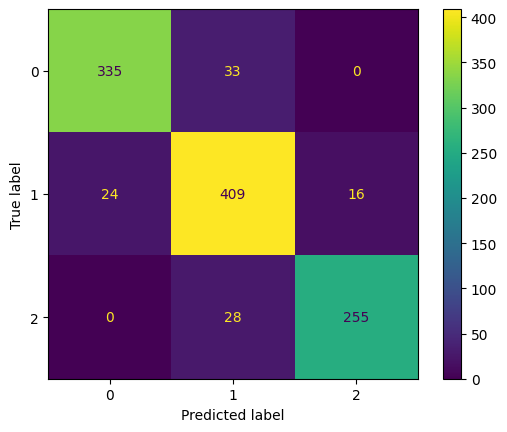

In [33]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred
)

plt.show()

In [34]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance

,Feature,Importance
2,systolic_bp,0.230009
4,cholesterol_mg_dl,0.166366
0,age,0.113673
3,diastolic_bp,0.106355
1,bmi,0.090285
8,physical_activity_hours_per_week,0.050770
6,daily_steps,0.041753
14,smoking_status_2,0.038098
11,diet_quality_score,0.034719
12,alcohol_units_per_week,0.028366


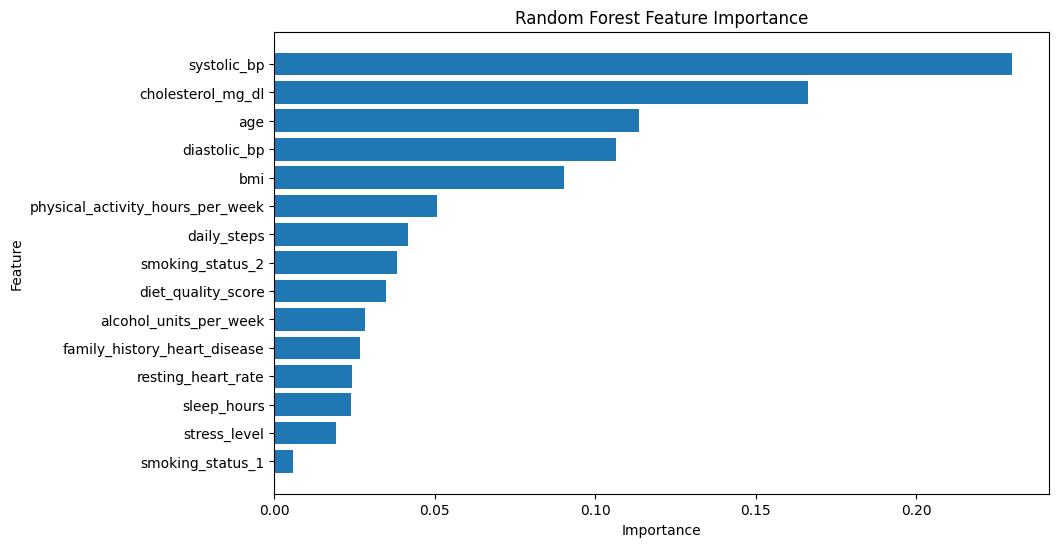

In [35]:
plt.figure(figsize=(10,6))

plt.barh(
    feature_importance['Feature'],
    feature_importance['Importance']
)

plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Random Forest Feature Importance')

plt.gca().invert_yaxis()

plt.show()